In [ ]:
# This program is for the book "Digital Image Processing" by Dr. Mahmood Azimi-Sadjadi.
# Copyright Copyright (c) 2026 Yifan Yang and Dr. Mahmood Azimi-Sadjadi.
# Contact: mahmood.azimi-sadjadi@colostate.edu

In [1]:
import tensorflow as tf
from tensorflow.keras import layers, Model, losses
import numpy as np
import matplotlib.pyplot as plt

# Load and normalize the dataset
(x_train, _), (x_test, _) = tf.keras.datasets.mnist.load_data()
x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

# x_train contains the training images, y_train contains the training labels
# x_test contains the test images, y_test contains the test labels

# Flatten the images to a 1D vector
x_train = x_train.reshape((len(x_train), np.prod(x_train.shape[1:])))
x_test = x_test.reshape((len(x_test), np.prod(x_test.shape[1:])))

print(x_train.shape)
print(x_test.shape)


class ContractiveAutoencoder(Model):
    def __init__(self, latent_dim, **kwargs):
        super(ContractiveAutoencoder, self).__init__(**kwargs)
        self.latent_dim = latent_dim
        self.encoder = tf.keras.Sequential([
            layers.Dense(128, activation='relu'),
            layers.Dense(latent_dim, activation='sigmoid') # Changed activation to sigmoid
        ])
        self.decoder = tf.keras.Sequential([
            layers.Dense(128, activation='relu'),
            layers.Dense(784, activation='sigmoid') # Changed output size to 3072 for CIFAR-10
        ])
        self.mse_loss = tf.keras.losses.MeanSquaredError()


    def call(self, x):
        encoded = self.encoder(x)
        decoded = self.decoder(encoded)
        return decoded

    def train_step(self, data):
        # Unpack the data.
        # Autoencoders don't need labels, so our data is just the input images.
        x = data

        with tf.GradientTape() as tape:
            # Perform forward pass
            encoded = self.encoder(x)
            reconstructed = self.decoder(encoded)

            # Reconstruction loss (e.g., Mean Squared Error)
            reconstruction_loss = self.mse_loss(x, reconstructed)
            reconstruction_loss = tf.reduce_mean(reconstruction_loss)

            # Contractive regularization loss
            # Calculate the Jacobian of the encoded layer with respect to the input
            # We must use persistent=True to reuse the tape
            with tf.GradientTape(persistent=True) as tape_jac:
                tape_jac.watch(x)
                encoded_jac = self.encoder(x)

            # Calculate the Jacobian using tf.GradientTape
            # Iterate through each output of the encoded layer and calculate the gradient with respect to the input
            jacobian_matrix = []
            for i in range(self.latent_dim):
                jacobian_row = tape_jac.gradient(encoded_jac[:, i], x)
                # Ensure gradients are not None, replace with zeros if necessary
                if jacobian_row is None:
                  jacobian_row = tf.zeros_like(x)
                jacobian_matrix.append(jacobian_row)


            # Stack the rows to form the Jacobian matrix
            jacobian_matrix = tf.stack(jacobian_matrix, axis=1)

            # Remove the inner `with` block as we are done with it
            del tape_jac

            # Calculate the squared Frobenius norm of the Jacobian
            # Sum over the last two dimensions (latent_dim, input_dim)
            jacobian_norm_sq = tf.reduce_sum(tf.square(jacobian_matrix), axis=[1, 2])
            contractive_loss = tf.reduce_mean(jacobian_norm_sq)

            # Total loss is the sum of reconstruction and contractive losses
            lambda_val = 1e-4  # Hyperparameter for contractive penalty
            total_loss = reconstruction_loss + lambda_val * contractive_loss

        # Get gradients of the loss with respect to the trainable weights.
        trainable_vars = self.trainable_variables
        gradients = tape.gradient(total_loss, trainable_vars)

        # Update the weights.
        self.optimizer.apply_gradients(zip(gradients, trainable_vars))

        # Return a dictionary mapping metric names to their current value.
        return {
            "loss": total_loss,
            "reconstruction_loss": reconstruction_loss,
            "contractive_loss": contractive_loss
        }

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
(60000, 784)
(10000, 784)


In [2]:
# Instantiate the model with a latent dimension of 32
cae = ContractiveAutoencoder(latent_dim=128)

# Compile the model with an optimizer
cae.compile(optimizer=tf.keras.optimizers.Adam())

# Train the model
cae.fit(x_train, epochs=10, batch_size=256) # Removed validation_data

Epoch 1/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 12s 43ms/step - contractive_loss: 0.0000e+00 - loss: 0.0443 - reconstruction_loss: 0.0443
Epoch 2/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 10s 45ms/step - contractive_loss: 0.0000e+00 - loss: 0.0284 - reconstruction_loss: 0.0284
Epoch 3/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 10s 43ms/step - contractive_loss: 0.0000e+00 - loss: 0.0246 - reconstruction_loss: 0.0246
Epoch 4/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 10s 43ms/step - contractive_loss: 0.0000e+00 - loss: 0.0178 - reconstruction_loss: 0.0178
Epoch 5/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 10s 42ms/step - contractive_loss: 0.0000e+00 - loss: 0.0171 - reconstruction_loss: 0.0171
Epoch 6/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 10s 41ms/step - contractive_loss: 0.0000e+00 - loss: 0.0153 - reconstruction_loss: 0.0153
Epoch 7/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 11s 45ms/step - contractive_loss: 0.0000e+00 - loss: 0.0154 - reconstruction_loss: 0.0154
Epoch 8/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 10s 43ms/step - contractive_loss: 0.0000e+00 - los

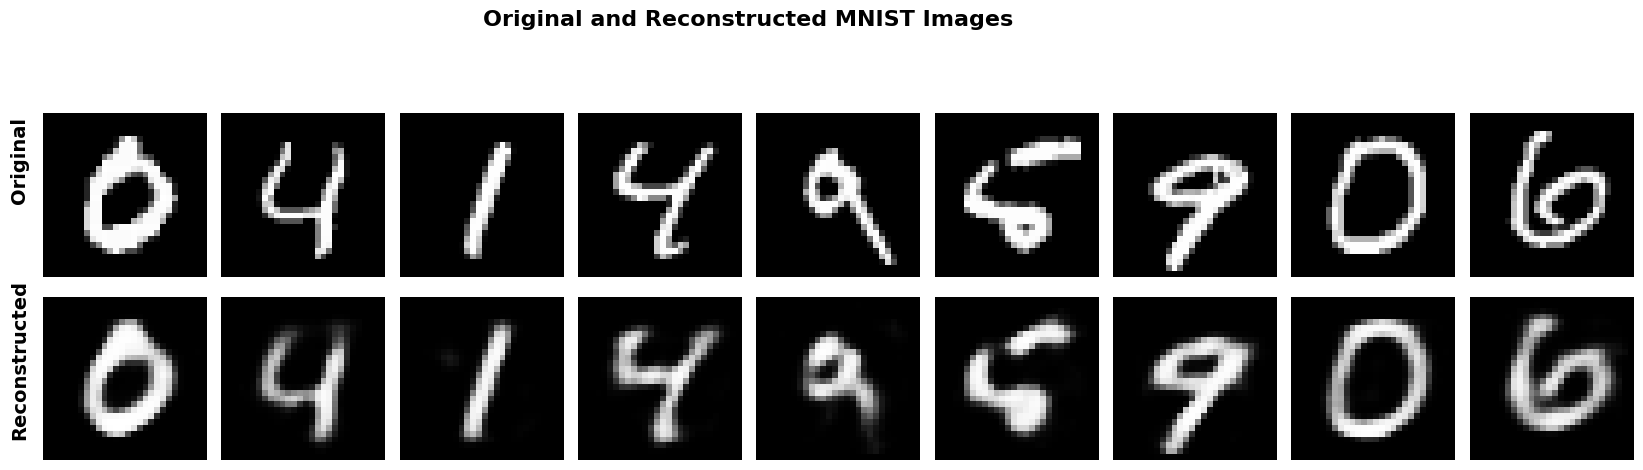

In [4]:
# Reconstruct the test images
reconstructed_images = cae.predict(x_test, verbose=0)

n_images = 9
start_index = 3

fig, axes = plt.subplots(2, n_images, figsize=(18, 5))

for i in range(n_images):
    image_index = start_index + i

    axes[0, i].imshow(
        x_test[image_index].reshape(28, 28),
        cmap="gray",
        vmin=0,
        vmax=1,
    )
    axes[0, i].axis("off")

    axes[1, i].imshow(
        reconstructed_images[image_index].reshape(28, 28),
        cmap="gray",
        vmin=0,
        vmax=1,
    )
    axes[1, i].axis("off")

fig.text(
    0.09,
    0.68,
    "Original",
    rotation=90,
    va="center",
    fontsize=14,
    fontweight="bold",
)

fig.text(
    0.09,
    0.28,
    "Reconstructed",
    rotation=90,
    va="center",
    fontsize=14,
    fontweight="bold",
)

fig.suptitle(
    "Original and Reconstructed MNIST Images",
    fontsize=16,
    fontweight="bold",
)

plt.tight_layout(rect=[0.1, 0, 1, 0.92])
plt.show()